In [2]:
import numpy as np
import matplotlib.pyplot as plt
import os

import matplotlib as mpl
import matplotlib.patches as mpatches
from matplotlib import rc
mpl.rcParams.update({
    'font.family' : 'Arial',
    'mathtext.fontset' : 'cm',
    'xtick.direction' : 'in' ,
    'xtick.labelsize' : 17.5 ,
    'xtick.top' : True ,
    'xtick.major.width' : 1.5,
    'xtick.major.size' : 6,
    'ytick.direction' : 'in' ,
    'ytick.labelsize' : 17.5 ,
    'ytick.right' : True ,
    'ytick.major.width' : 1.5,
    'ytick.major.size' : 6,
    'axes.labelsize' : 18,
    'legend.frameon' : False,
    'legend.fontsize' : 13,
    'legend.handlelength' : 2,
    'savefig.dpi' : 600, 
    'savefig.bbox' : 'tight',
    'axes.linewidth' : 1.5,
})
import matplotlib.ticker as ticker
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
import seaborn as sns

print(plt.rcParams['font.family'])

['Arial']


In [3]:
def is_non_zero_file(fpath, verb=False):
    result = os.path.isfile(fpath) and os.path.getsize(fpath) > 0
    return result

depths = [2,4,6,8,10,12,14,16,18,20]
size_D = [17, 24, 31]
size_R = [20, 25, 30, 36]
color = sns.color_palette()

In [4]:
size_color = ['#BD4032', '#D3770D', '#15A2A0', '#1879BF'][::-1]
size_color = ['#006493', '#9763ad', '#f15f75', '#e79d14']
size_format = ['^-', 's-', 'D-', 'o-']
size_ms = [10,8,8,10]

[1.07104158 1.03739757 1.00028619 1.00007936 1.0000635  1.00006375
 1.00005795 1.00005444 1.00005126]


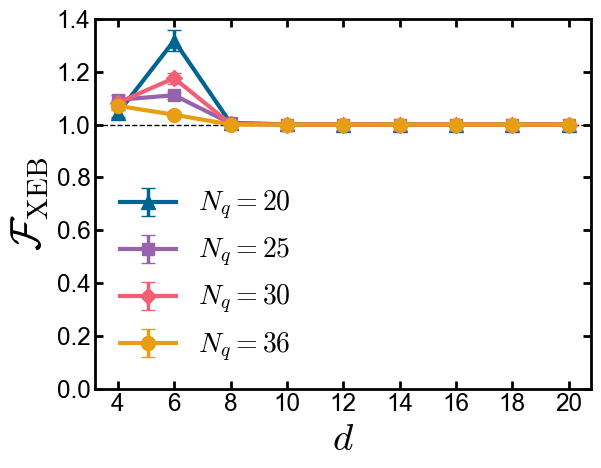

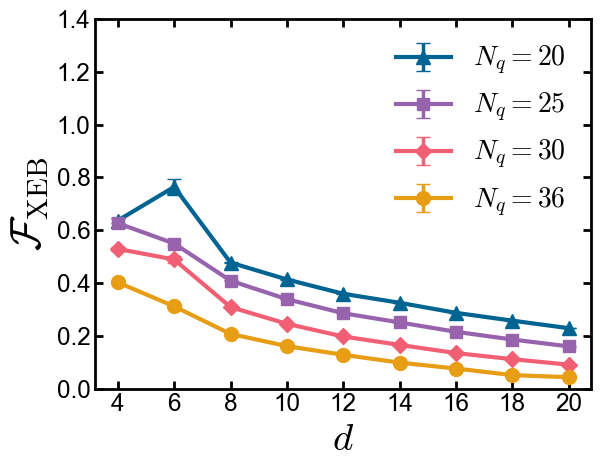

In [6]:
mpl.rcParams['axes.linewidth'] = 2

for n, ss in enumerate(size_R):
    npz = np.load(f'Data_out/g2_saved_models_rqc/XEB_{ss}.npz')
    ee = npz['f'].mean(axis=1)
    eef = npz['f'].std(axis=1)/np.sqrt(50)
    plt.errorbar(depths[1:], ee[1:], yerr=eef[1:], c=size_color[n], \
                 capsize=5, lw=3, elinewidth=2.5, ms=size_ms[n], fmt=size_format[n], label=fr'$N_q={ss}$')
print(ee[1:])
plt.xticks(depths[1:])
plt.gca().xaxis.set_tick_params(width=2)
plt.gca().yaxis.set_tick_params(width=2)
plt.axhline(1, c='k', ls='--', lw=1)
plt.xlabel(r'$d$', fontsize=28)
plt.ylabel(r'$\mathcal{F}_\mathrm{XEB}$', fontsize=30)
plt.ylim(0,1.4)
plt.legend(fontsize=20)
plt.savefig('fig3d.png', dpi = 400)
plt.show()

for n, ss in enumerate(size_R):
    npz = np.load(f'Data_out/g2_saved_models_rqc/XEB_{ss}.npz')
    ee = npz['e'].mean(axis=1)
    eef = npz['e'].std(axis=1)/np.sqrt(50)
    plt.errorbar(depths[1:], ee[1:], yerr=eef[1:], c=size_color[n], \
                 capsize=5, lw=3, elinewidth=2.5, ms=size_ms[n], fmt=size_format[n], label=fr'$N_q={ss}$')

plt.xticks(depths[1:])
plt.gca().xaxis.set_tick_params(width=2)
plt.gca().yaxis.set_tick_params(width=2)
plt.xlabel(r'$d$', fontsize=28)
plt.ylabel(r'$\mathcal{F}_\mathrm{XEB}$', fontsize=30)
plt.ylim(0,1.4)
plt.legend(fontsize=20)
plt.savefig('fig3f.png', dpi = 400)


9.278469909242295 9.500000953673407
11.638999511777657 11.750000022351742
14.27809290720722 14.500000000931323


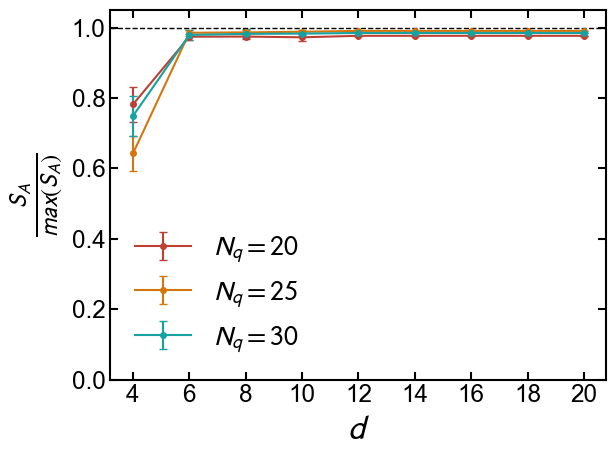

In [8]:
for i, ss in enumerate(size_R):
    n = 1
    if not is_non_zero_file(f'Data_out/g2_saved_models_rqc/EE_{ss}.npz'): continue
    npz = np.load(f'Data_out/g2_saved_models_rqc/EE_{ss}.npz')['e']
    npz[-1, 13] = npz[-1, 12]
    ee = npz[:,npz.mean(axis=0)!=0].mean(axis=1)
    eef = npz[:,npz.mean(axis=0)!=0].std(axis=1)/np.sqrt(np.sum(npz.mean(axis=0)!=0)) #(npz[:,npz.mean(axis=0)!=0].std(axis=1)/ee.min())**2
    eemax = ss//2 * np.log2(2) - (2**(2*(ss//2))-1) / (2*(2**ss + 1))
    print(-ee.min(), eemax)
    plt.errorbar(depths[n:], -ee[n:]/eemax, yerr=eef[n:], \
                 fmt='.-', c=size_color[i], capsize=3, ms=8, label=fr'$N_q={ss}$')
plt.xticks(depths[1:])
plt.ylim(0,1.05)
plt.axhline(1, c='k', ls='--', lw=1)
#plt.title('Rectangle sim XEB', fontsize=18)
plt.xlabel(r'$d$', fontsize=25)
plt.ylabel(r'$\frac{S_A}{max(S_A)}$', fontsize=25)

plt.legend(fontsize=20)
# plt.savefig('fig4d.png', dpi = 400)
plt.show()

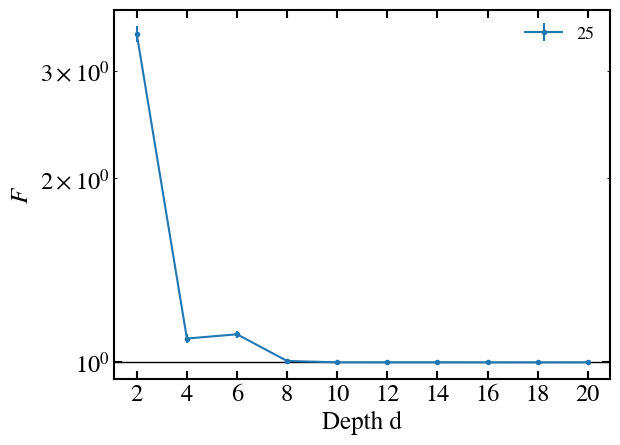

In [16]:
depths = [2,4,6,8,10,12,14,16,18,20]
for ss in size_R:
    if ss!=25: continue
    npz = np.load(f'Data_out/g2_saved_models_rqc/XEB_{ss}.npz')
    ee = npz['f'].mean(axis=1)
    eef = npz['f'].std(axis=1)/np.sqrt(50)
    plt.errorbar(depths, ee, yerr=eef, fmt='.-', label=f'{ss}')
plt.yscale('log')
plt.xticks(depths)
plt.axhline(1, c='k', lw=1)
plt.xlabel('Depth d', fontsize=18)
plt.ylabel(r'$F$', fontsize=18)
plt.legend()
plt.show()
